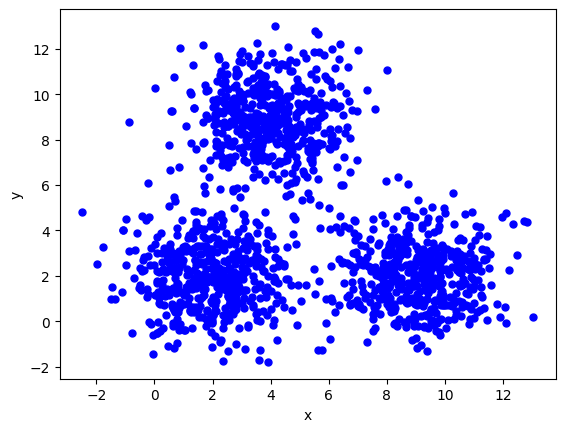

[[ 3.23391358 11.69020685]
 [ 3.13886774  1.38576035]
 [ 9.50200173  2.1627093 ]]


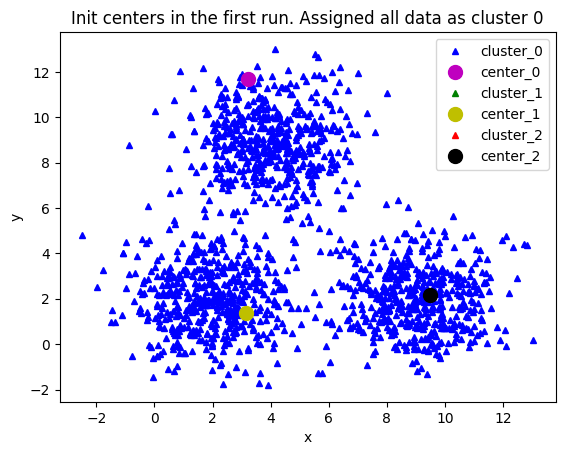

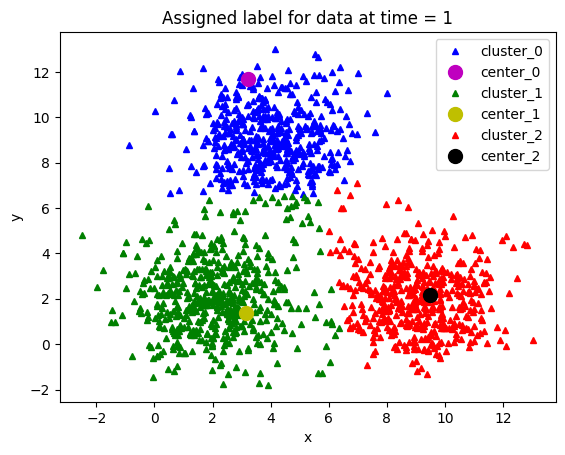

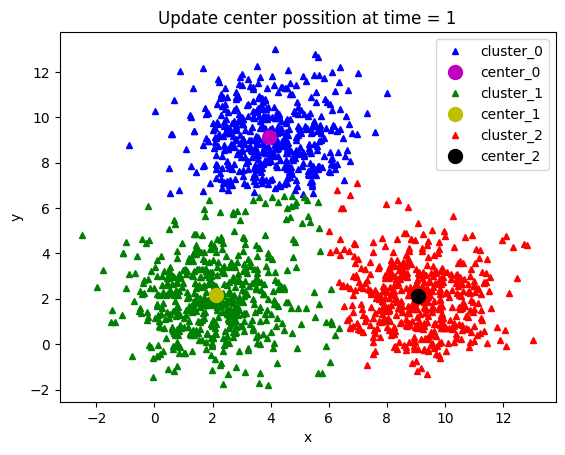

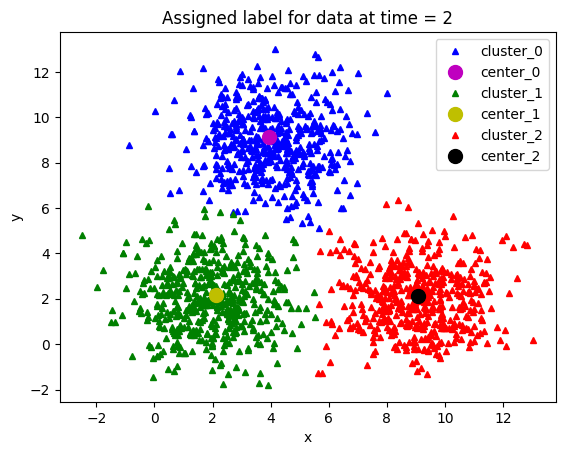

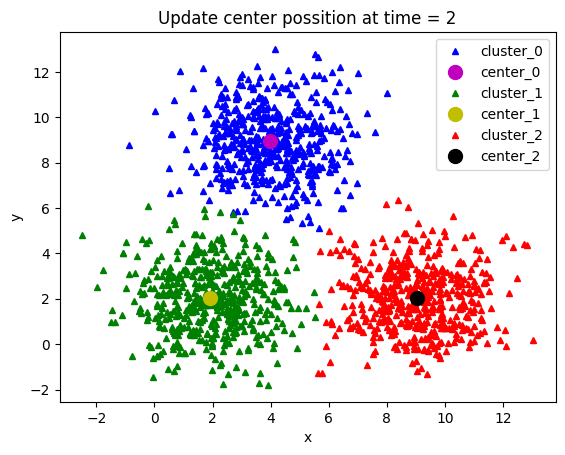

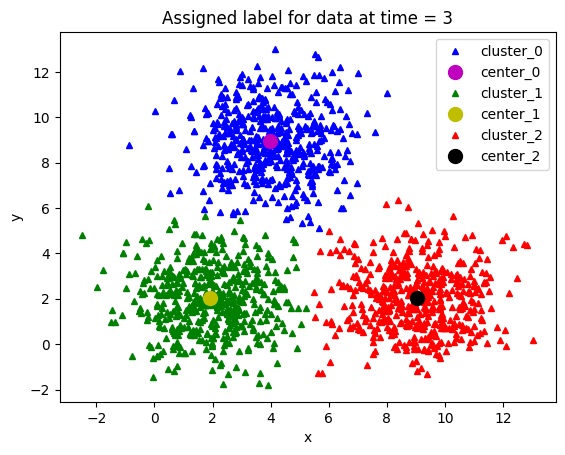

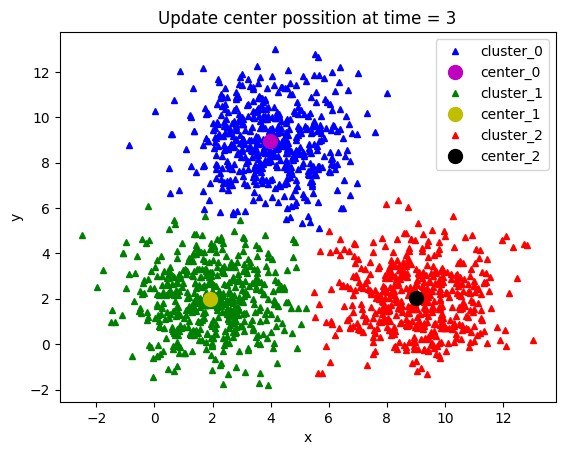

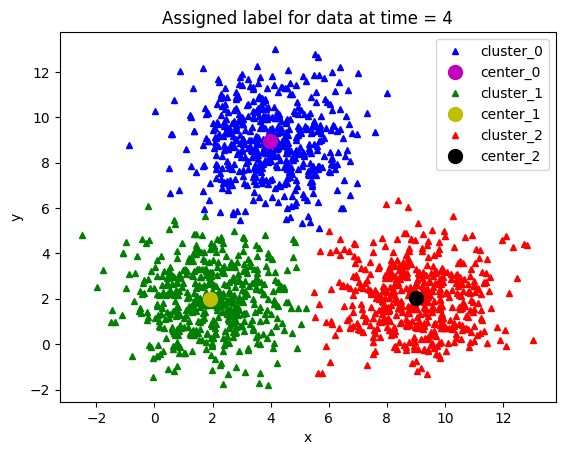

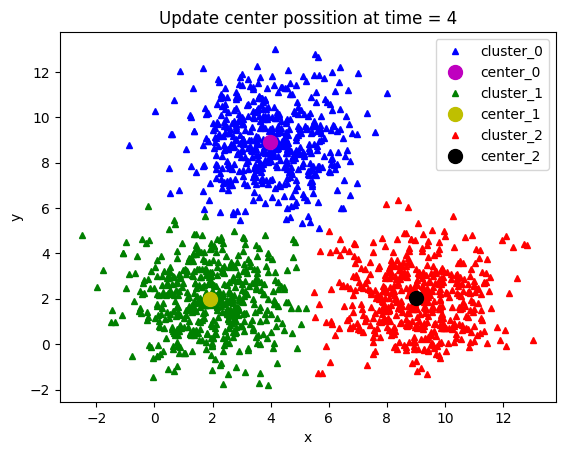

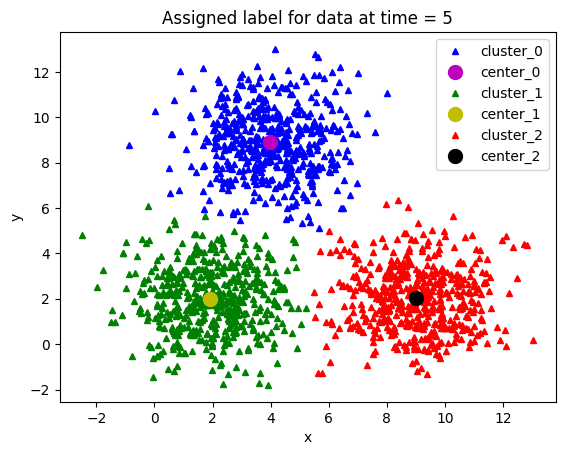

Done! Kmeans has converged after 4 times
[[3.96887204 8.92773329]
 [1.90039323 1.98758742]
 [9.01371611 2.0237499 ]]


In [ ]:
#Bài Tập Mẫu K-Means

import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial.distance import cdist
means = [[2, 2], [9, 2], [4, 9]]
cov = [[2, 0], [0, 2]]
n_samples = 500
n_cluster = 3
X0 = np.random.multivariate_normal(means[0], cov, n_samples)
X1 = np.random.multivariate_normal(means[1], cov, n_samples)
X2 = np.random.multivariate_normal(means[2], cov, n_samples)
X = np.concatenate((X0, X1, X2), axis = 0)
plt.xlabel('x')
plt.ylabel('y')
plt.plot(X[:, 0], X[:, 1], 'bo', markersize=5)
plt.plot()
plt.show()
def kmeans_init_centers(X, n_cluster):
  return X[np.random.choice(X.shape[0], n_cluster, replace=False)]
def kmeans_predict_labels(X, centers):
  D = cdist(X, centers)
  return np.argmin(D, axis = 1)
def kmeans_update_centers(X, labels, n_cluster):
  centers = np.zeros((n_cluster, X.shape[1]))
  for k in range(n_cluster):
    Xk = X[labels == k, :]
    centers[k,:] = np.mean(Xk, axis = 0)
  return centers
def kmeans_has_converged(centers, new_centers):
  return (set([tuple(a) for a in centers]) ==
      set([tuple(a) for a in new_centers]))
def kmeans_visualize(X, centers, labels, n_cluster, title):
  plt.xlabel('x')
  plt.ylabel('y')
  plt.title(title)
  plt_colors = ['b', 'g', 'r', 'c', 'm', 'y', 'k', 'w']

  for i in range(n_cluster):
    data = X[labels == i]
    plt.plot(data[:, 0], data[:, 1], plt_colors[i] + '^', markersize=4,
             label='cluster_' + str(i))
    plt.plot(centers[i][0], centers[i][1], plt_colors[i + 4] + 'o', markersize=10,
             label='center_' + str(i))
  plt.legend()
  plt.show()
def kmeans(init_centes, init_labels, X, n_cluster):
  centers = init_centes
  labels = init_labels
  times = 0
  while True:
    labels = kmeans_predict_labels(X, centers)
    kmeans_visualize(X, centers, labels, n_cluster, 'Assigned label for data at time = ' + str(times + 1))
    new_centers = kmeans_update_centers(X, labels, n_cluster)
    if kmeans_has_converged(centers, new_centers):
      break
    centers = new_centers
    kmeans_visualize(X, centers, labels, n_cluster, 'Update center possition at time = ' + str(times + 1))
    times += 1
  return (centers, labels, times)
init_centers = kmeans_init_centers(X, n_cluster)
print(init_centers)
init_labels = np.zeros(X.shape[0])
kmeans_visualize(X, init_centers, init_labels, n_cluster,
                 'Init centers in the first run. Assigned all data as cluster 0')
centers, labels, times = kmeans(init_centers, init_labels, X, n_cluster)

print('Done! Kmeans has converged after', times, 'times')
print(centers)

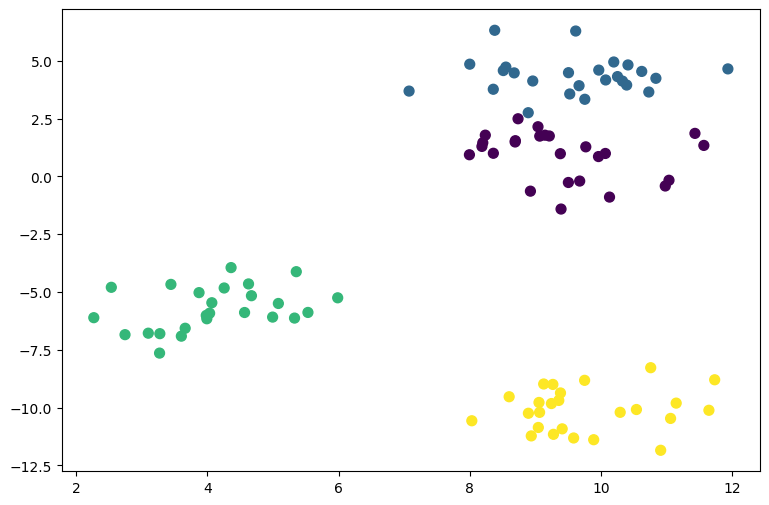

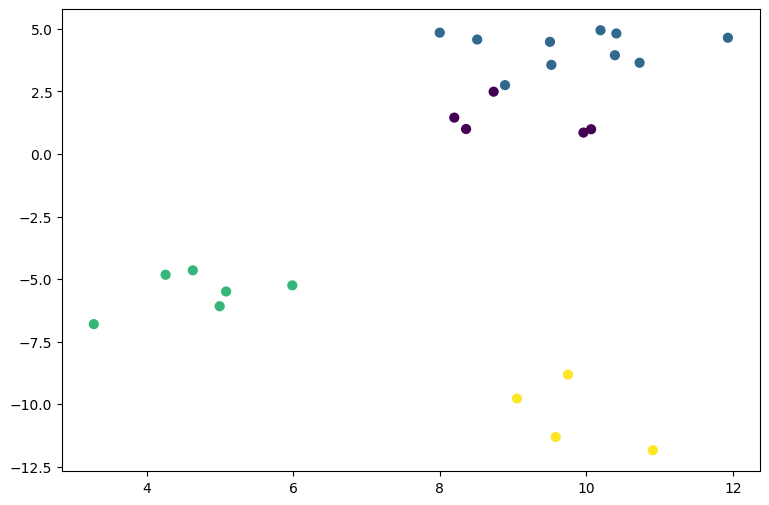

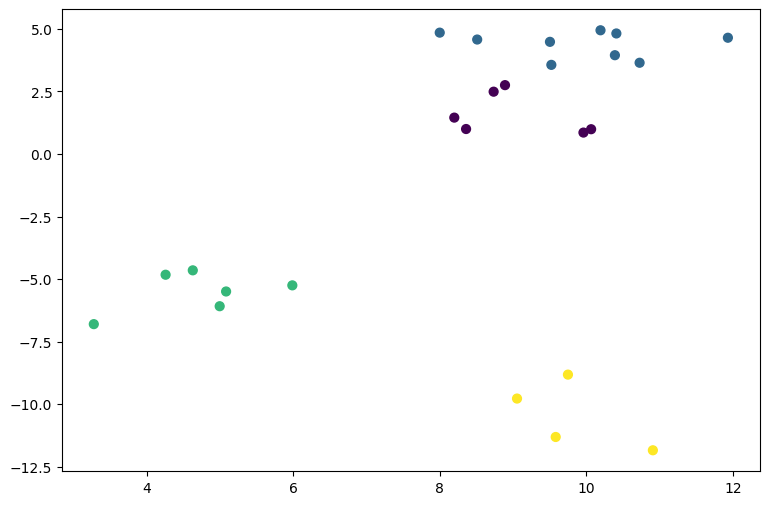

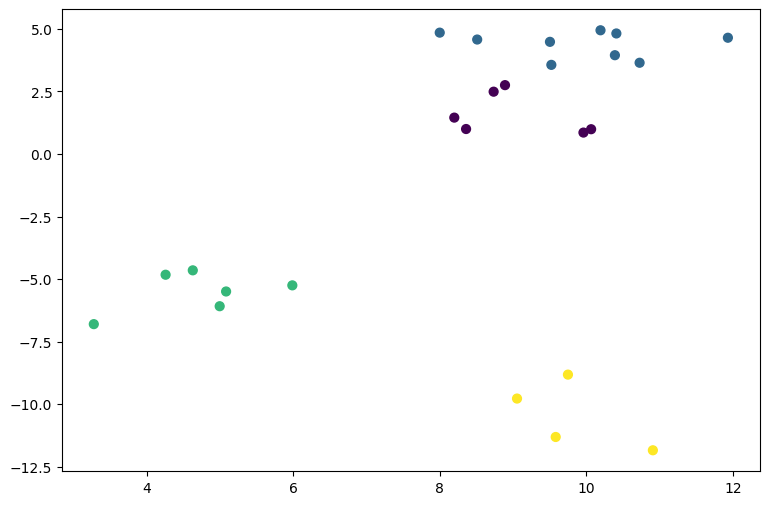

In [ ]:
#Bài Tập Mẫu K-NN -- Cách 1

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
X,y = make_blobs(n_samples = 100, n_features = 2, centers = 4, cluster_std = 1, random_state = 4)

plt.figure(figsize=(9, 6))
plt.scatter(X[:, 0], X[:, 1], c=y, marker='o', s=50)
plt.show()
X_train, X_test, y_train, y_test = train_test_split(X,y,random_state=0)

plt.figure(figsize = (9,6))
plt.scatter(X_test[:,0], X_test[:,1], c=y_test, marker= 'o', s=40)
plt.show()
knn5 = KNeighborsClassifier(5)
knn5.fit(X_train, y_train)

y_pred_5 = knn5.predict(X_test)

plt.figure(figsize = (9,6))
plt.scatter(X_test[:,0], X_test[:,1], c=y_pred_5, marker= 'o', s=40)
plt.show()
knn1 = KNeighborsClassifier(1)
knn1.fit(X_train, y_train)

y_pred_1 = knn1.predict(X_test)

plt.figure(figsize = (9,6))
plt.scatter(X_test[:,0], X_test[:,1], c=y_pred_1, marker= 'o', s=40)
plt.show()


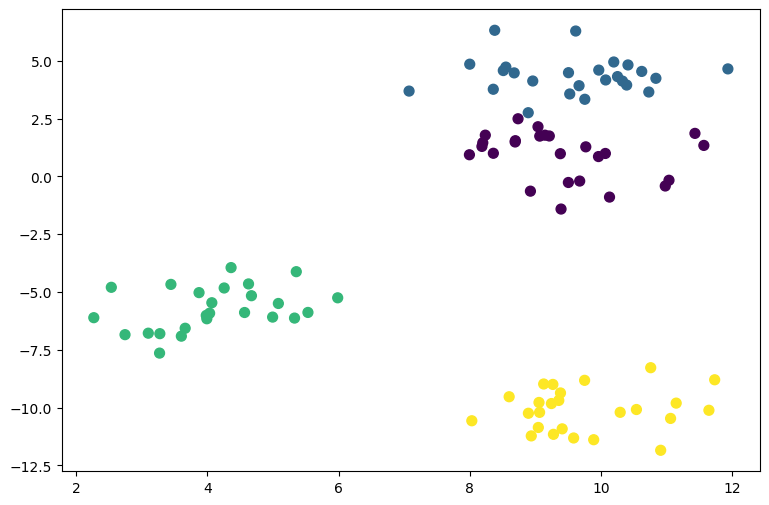

{'n_neighbors': np.int64(2)}
[0]


In [ ]:
#Bài Tập Mẫu K-NN -- Cách 2

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
X,y = make_blobs(n_samples = 100, n_features = 2, centers = 4, cluster_std = 1, random_state = 4)
plt.figure(figsize=(9, 6))
plt.scatter(X[:, 0], X[:, 1], c=y, marker='o', s=50)
plt.show()
from sklearn.model_selection import GridSearchCV

knn_grid = GridSearchCV(estimator = KNeighborsClassifier(), param_grid={'n_neighbors': np.arange(1,10)}, cv=5)
knn_grid.fit(X,y)

print (knn_grid.best_params_)
def KNN(X_train,X_test,y_train,k):
    num_test = X_test.shape[0]
    num_train = X_train.shape[0]
    y_pred = np.zeros((num_test,num_train))
    for i in range(num_test):
        for j in range(num_train):
            y_pred[i,j] = np.sqrt(np.sum(np.power(X_test[i,:]-X_train[j,:],2)))
    results = []
    for i in range(len(y_pred)):
        zipped = zip(y_pred[i,:],y_train)
        res = sorted(zipped,key = lambda x:x[0])
        results_topk = res[:k]
        classes = {}
        for _,j in results_topk:
            j = int(j)
            if j not in classes:
                classes[j] = 1
            else:
                classes[j] = classes[j] + 1
        results.append(max(classes,key = classes.get))
    return np.array(results)

(X,y) = make_blobs(n_samples = 500, n_features = 2, centers = 4, cluster_std = 1, random_state = 4)
X_test=np.array([(1,3)])
results = KNN(X,X_test,y,3)
print (results)


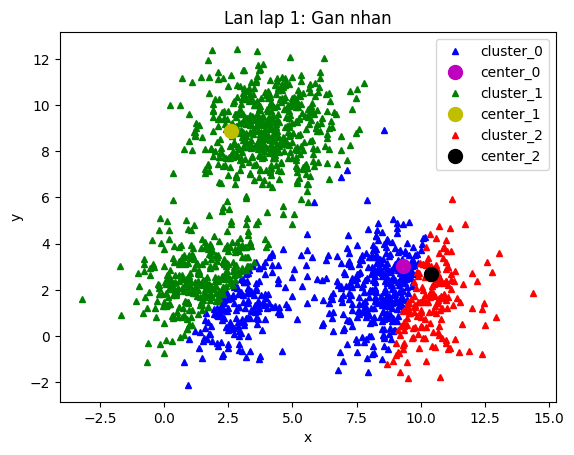

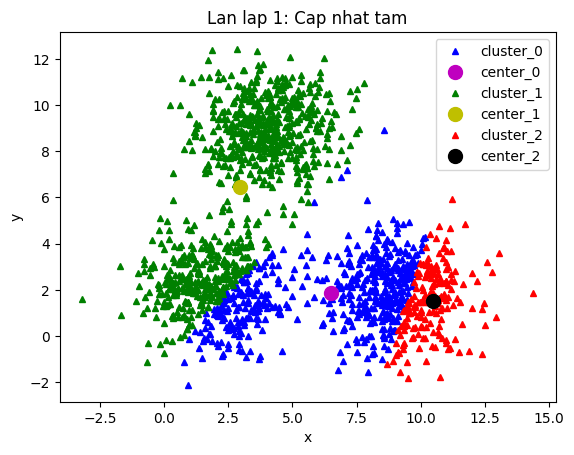

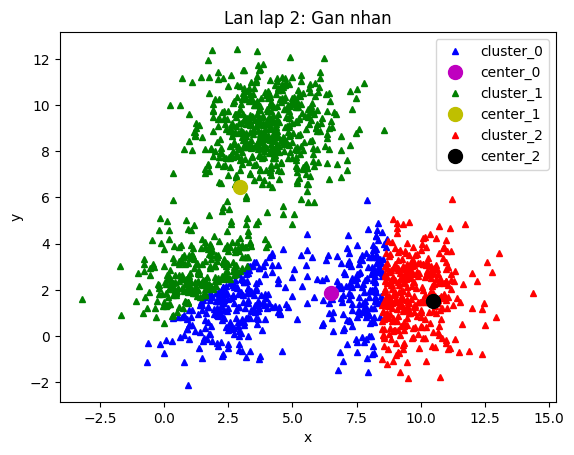

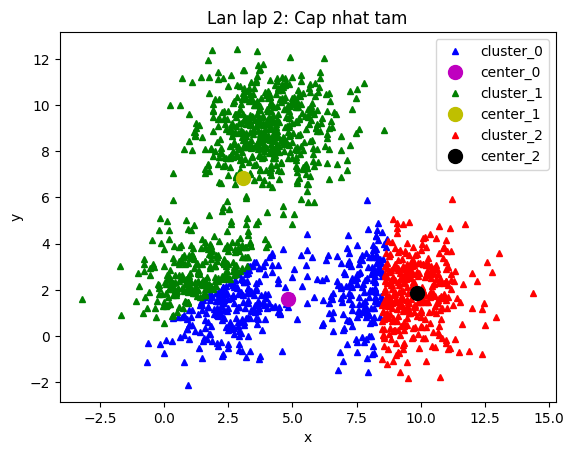

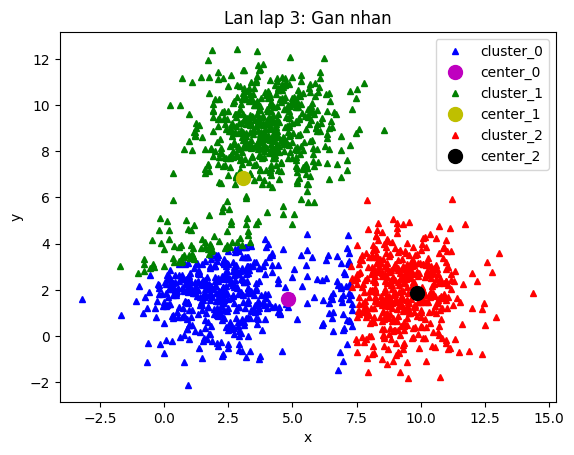

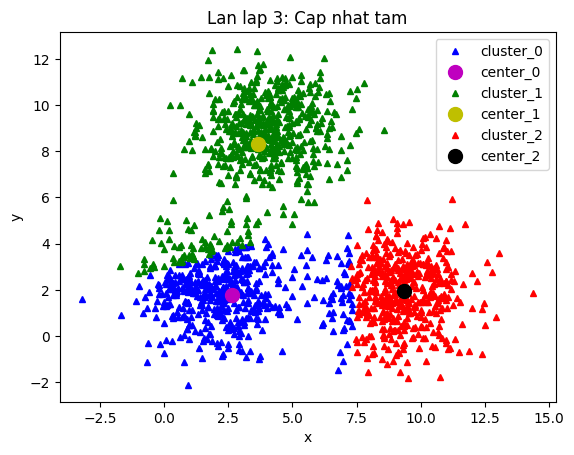

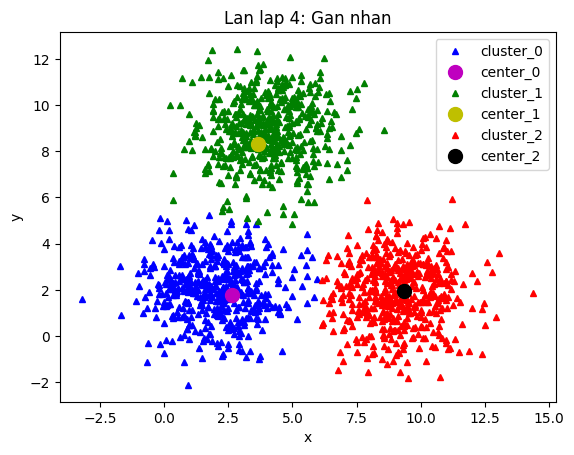

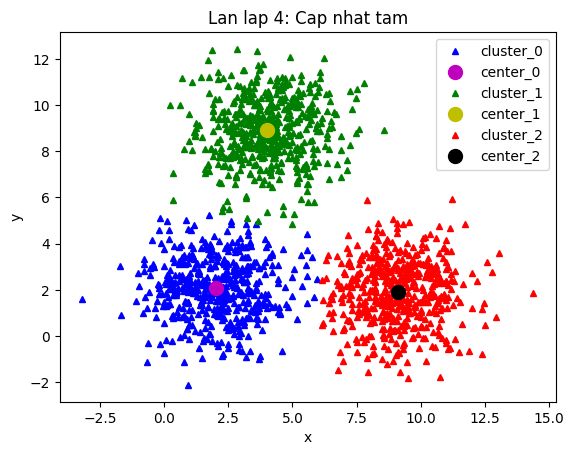

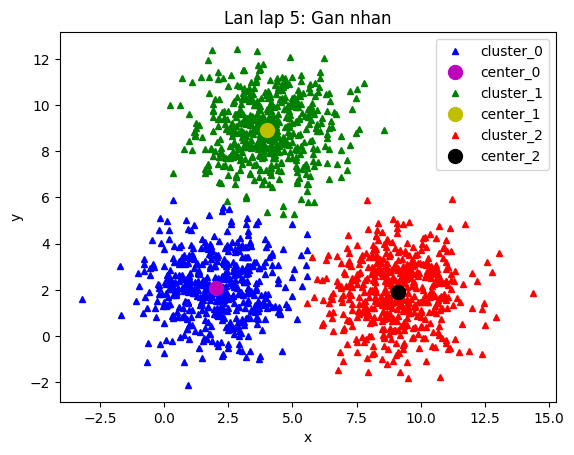

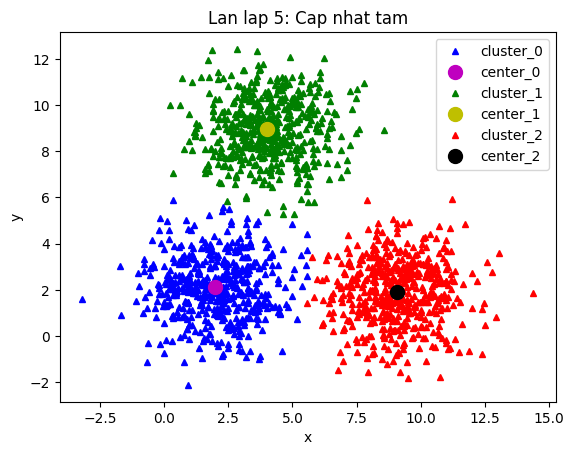

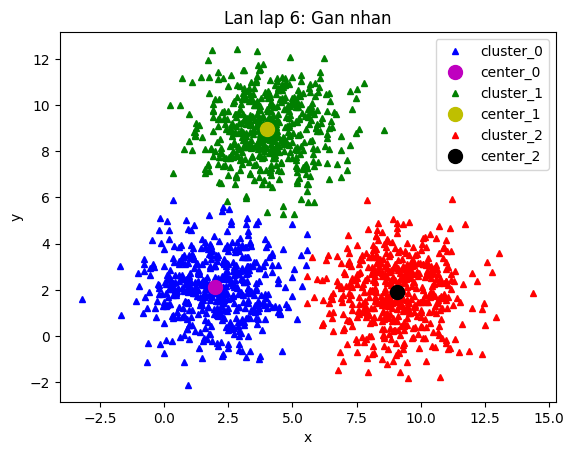

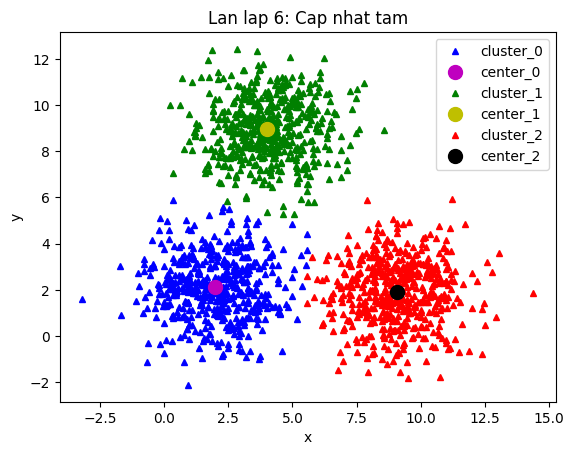

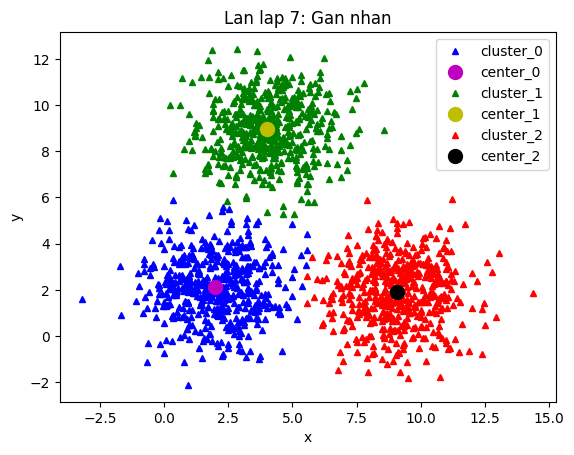

In [ ]:
#Bài tập tại lớp bài 1 - Cài đặt lại thuật toán k-means.

import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial.distance import cdist

means = [[2, 2], [9, 2], [4, 9]]
cov = [[2, 0], [0, 2]]
X0 = np.random.multivariate_normal(means[0], cov, 500)
X1 = np.random.multivariate_normal(means[1], cov, 500)
X2 = np.random.multivariate_normal(means[2], cov, 500)
X = np.concatenate((X0, X1, X2), axis = 0)

def kmeans_visualize(X, centers, labels, n_cluster, title):
    plt.xlabel('x')
    plt.ylabel('y')
    plt.title(title)
    plt_colors = ['b', 'g', 'r', 'c', 'm', 'y', 'k', 'w']
    for i in range(n_cluster):
        data = X[labels == i]

        plt.plot(data[:, 0], data[:, 1], plt_colors[i] + '^', markersize=4, label='cluster_' + str(i))

        plt.plot(centers[i][0], centers[i][1], plt_colors[i + 4] + 'o', markersize=10, label='center_' + str(i))
    plt.legend()
    plt.show()

def kmeans(X, n_cluster):
    centers = X[np.random.choice(X.shape[0], n_cluster, replace=False)]
    labels = np.zeros(X.shape[0])
    times = 0

    while True:
        D = cdist(X, centers)
        labels = np.argmin(D, axis = 1)
        kmeans_visualize(X, centers, labels, n_cluster, f'Lan lap {times + 1}: Gan nhan')
        new_centers = np.zeros((n_cluster, X.shape[1]))
        for k in range(n_cluster):
            Xk = X[labels == k, :]
            new_centers[k,:] = np.mean(Xk, axis = 0)
        if (set([tuple(a) for a in centers]) == set([tuple(a) for a in new_centers])):
            break
        centers = new_centers
        kmeans_visualize(X, centers, labels, n_cluster, f'Lan lap {times + 1}: Cap nhat tam')
        times += 1
    return centers, labels

centers, labels = kmeans(X, 3)

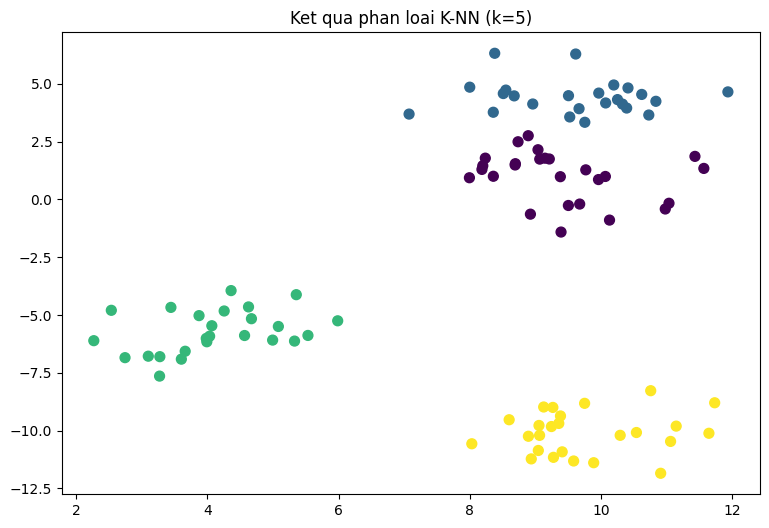

Điểm (1, 3) được dự đoán thuộc nhóm: [1]


In [ ]:
#Bài tập tại lớp bài 2,3 - Cài đặt lại thuật toán k-means. Cài đặt ứng dụng demo cho 2 thuật toán trên.

from sklearn.datasets import make_blobs
from sklearn.neighbors import KNeighborsClassifier
import matplotlib.pyplot as plt


X, y = make_blobs(n_samples=100, n_features=2, centers=4, cluster_std=1, random_state=4)


knn5 = KNeighborsClassifier(n_neighbors=5)
knn5.fit(X, y)
y_pred = knn5.predict(X)

plt.figure(figsize=(9, 6))
plt.scatter(X[:, 0], X[:, 1], c=y_pred, marker='o', s=50)
plt.title("Ket qua phan loai K-NN (k=5)")
plt.show()

def KNN_custom(X_train, X_test, y_train, k):
    num_test = X_test.shape[0]
    num_train = X_train.shape[0]
    results = []
    for i in range(num_test):
        distances = np.sqrt(np.sum(np.power(X_train - X_test[i, :], 2), axis=1))
        nearest_partition = np.argpartition(distances, k)[:k]
        top_k_labels = y_train[nearest_partition]
        unique, counts = np.unique(top_k_labels, return_counts=True)
        results.append(unique[np.argmax(counts)])
    return np.array(results)

test_point = np.array([(1, 3)])
prediction = KNN_custom(X, test_point, y, k=3)
print(f"Điểm (1, 3) được dự đoán thuộc nhóm: {prediction}")